In [1]:
import glob
import numpy as np
import scipy.signal as scs
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import CESfunctionsIASC as cf

In [2]:
no2 = np.load('NO2_IASC_CEAS450.npy')
gly = np.load('CHOCHO_IASC_CEAS450.npy')
ray = np.load('sigma_ray_CEAS450.npy')
print(no2.shape,gly.shape,ray.shape)

(1024, 2) (1024, 2) (1024,)


In [3]:
im = np.loadtxt('Im.txt')
ib = np.loadtxt('Ib.txt')
I_0 = np.average(ib[:,:],axis=1).reshape(len(ib),1)
ext = cf.extinction_w_ray(im[:,1].reshape(len(im),1),I_0,.99926,480,101335,293.15,ray.reshape(len(ib),1))

In [4]:
ext.shape

(1024, 1)

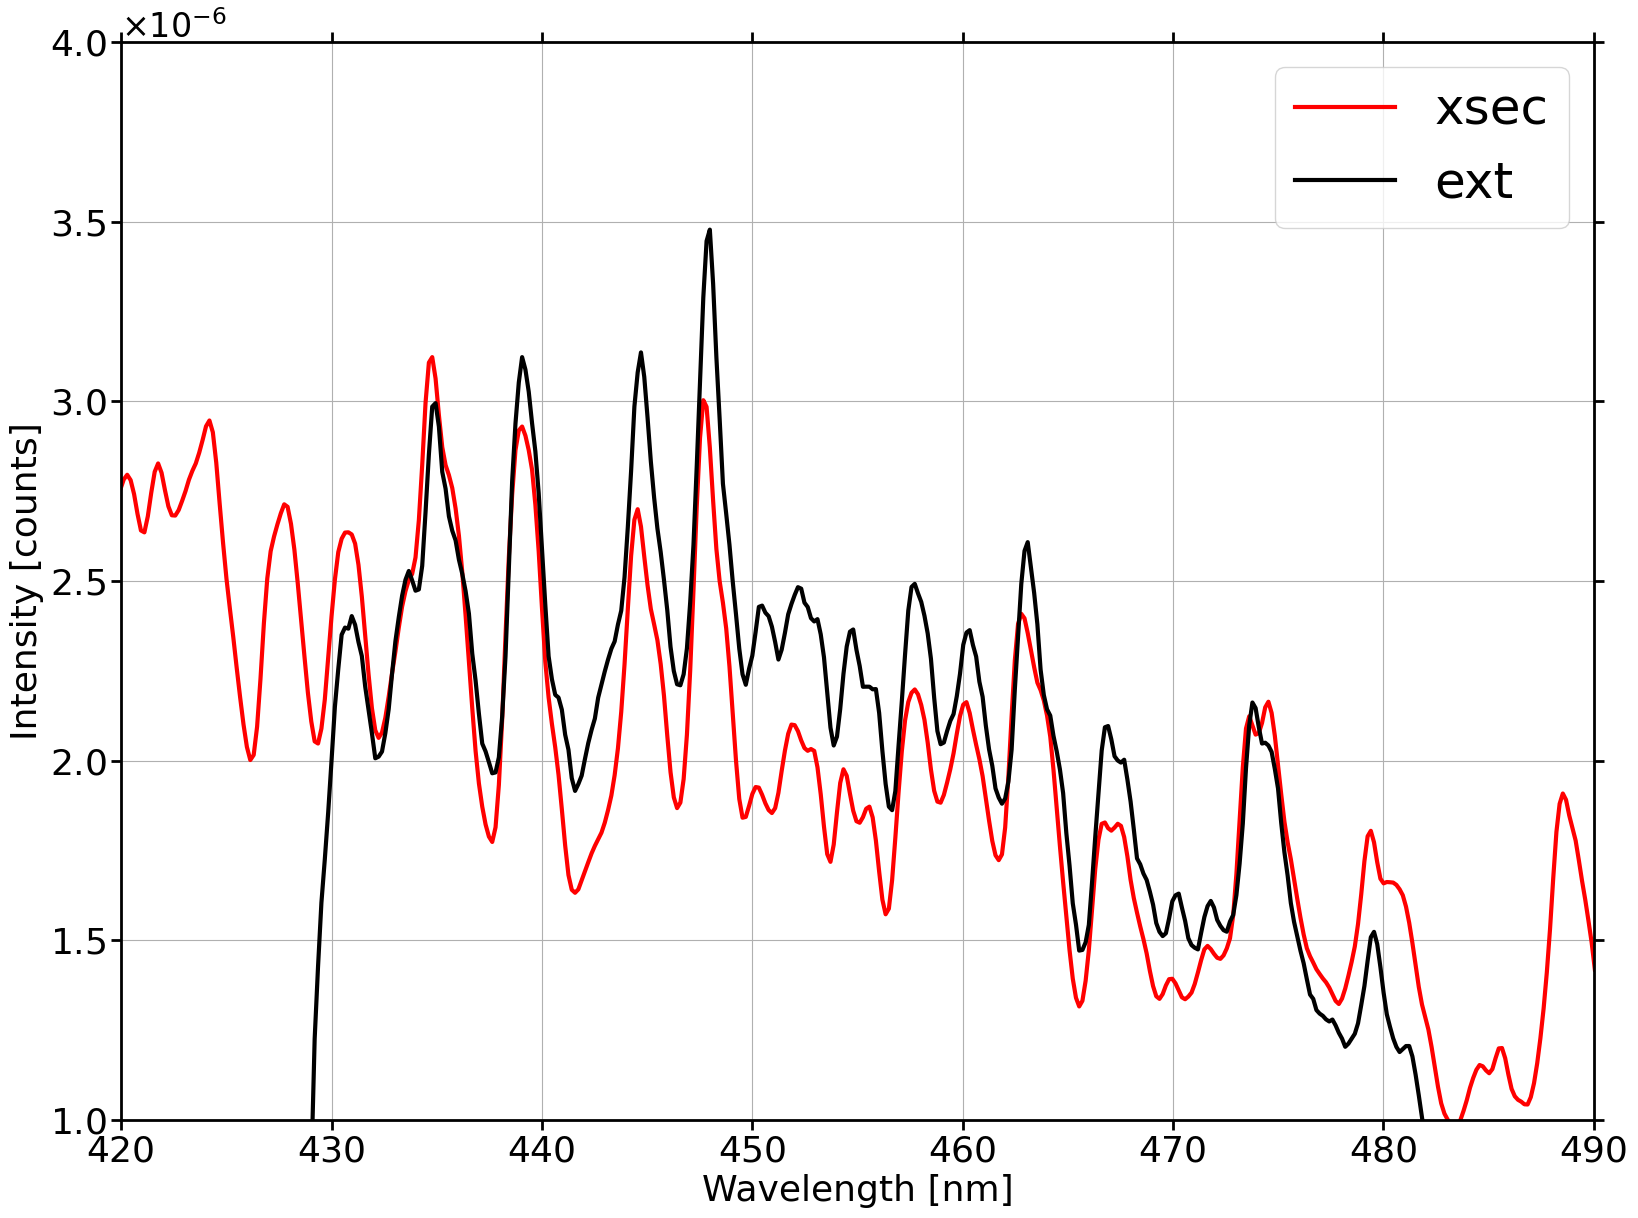

In [8]:
f = plt.figure(figsize=(19,14))
ax1 = f.add_subplot(111)
ax1.plot(no2[:,0],no2[:,1]*2.5e10*90+1e-6,'-r',linewidth=3.0,alpha=1, label="xsec")
ax1.plot(wvls,ext,'-k',linewidth=3.0,alpha=1, label="ext")

ax1.set_xlim(420,490)
ax1.set_ylim(1e-6,4e-6)


ax1.set_xlabel('Wavelength [nm]',size=26)
ax1.set_ylabel('Intensity [counts]',size=26)
#ax1.set_title("NO$_2$ measurements, 24/04",size=16)

#ax1.legend(fontsize=26, loc='upper right', bbox_to_anchor=(0.94, 0.99))
ax1.legend(fontsize=36, loc='upper right')

ax1.tick_params(which='both', width=2)
ax1.tick_params(which='major', length=7,labelsize=26,top=True, right=True)
ax1.tick_params(which='minor', length=4,top=True, right=True)
#ax1.xaxis.set_minor_locator(AutoMinorLocator(3))
#ax1.yaxis.set_minor_locator(AutoMinorLocator())
#plt.vlines(dt.datetime(2024,4,10,14,0),0,50, colors='k', linestyles= 'dashed')
#plt.vlines(dt.datetime(2024,4,10,15,30),0,50, colors='k', linestyles= 'dashed')
ax1.yaxis.offsetText.set_fontsize(24)
ax1.ticklabel_format(axis='y', style='sci',useMathText=True)
ax1.grid()
for axis in ['top', 'bottom', 'left', 'right']:
    ax1.spines[axis].set_linewidth(2)

In [33]:
np.savetxt('ext.txt',ext)
np.savetxt('no2.txt',no2)

In [6]:
wvl=[430.8975,435.0167,439.1246,444.6327,447.9233,457.8722,460.3377,462.9467,466.9141,473.8594,479.5179]
pixel=[509,534,560,596,617,680,697,715,740,785,823]

In [7]:
coefs = np.polyfit(pixel,wvl,3)
print(coefs,coefs[::-1])
pixels = np.arange(1,1025)
wvls = cf.andor_calibrator(1024,*coefs[::-1])

[ 2.56661171e-08 -6.38963777e-05  2.05091521e-01  3.39736352e+02] [ 3.39736352e+02  2.05091521e-01 -6.38963777e-05  2.56661171e-08]


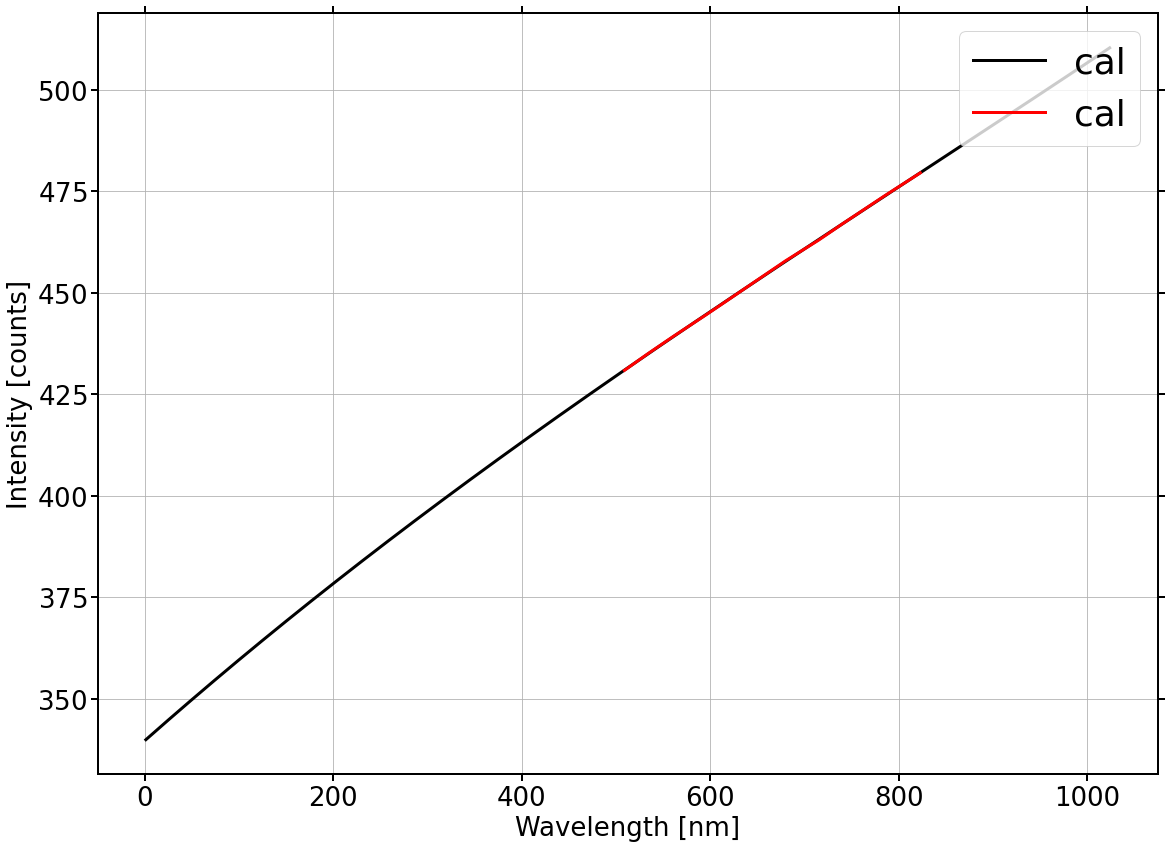

In [38]:
f = plt.figure(figsize=(19,14))
ax1 = f.add_subplot(111)
ax1.plot(pixels,wvls,'-k',linewidth=3.0,alpha=1, label="cal")
ax1.plot(pixel,wvl,'-r',linewidth=3.0,alpha=1, label="cal")


#ax1.set_xlim(420,490)
#ax1.set_ylim(1e-6,4e-6)


ax1.set_xlabel('Wavelength [nm]',size=26)
ax1.set_ylabel('Intensity [counts]',size=26)
#ax1.set_title("NO$_2$ measurements, 24/04",size=16)

#ax1.legend(fontsize=26, loc='upper right', bbox_to_anchor=(0.94, 0.99))
ax1.legend(fontsize=36, loc='upper right')

ax1.tick_params(which='both', width=2)
ax1.tick_params(which='major', length=7,labelsize=26,top=True, right=True)
ax1.tick_params(which='minor', length=4,top=True, right=True)
#ax1.xaxis.set_minor_locator(AutoMinorLocator(3))
#ax1.yaxis.set_minor_locator(AutoMinorLocator())
#plt.vlines(dt.datetime(2024,4,10,14,0),0,50, colors='k', linestyles= 'dashed')
#plt.vlines(dt.datetime(2024,4,10,15,30),0,50, colors='k', linestyles= 'dashed')
ax1.yaxis.offsetText.set_fontsize(24)
ax1.ticklabel_format(axis='y', style='sci',useMathText=True)
ax1.grid()
for axis in ['top', 'bottom', 'left', 'right']:
    ax1.spines[axis].set_linewidth(2)